In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import geopandas as gpd

import sklearn
from sklearn.cluster import KMeans
sklearn.set_config(transform_output='pandas')

In [3]:
import matplotlib.pyplot as plt
import contextily as ctx

import folium

In [4]:
import dataset as ds

# Load EVSE Dataset

In [5]:
DATA_PATH = os.path.join('.', 'data')
DATA_NAME, SR_FREQ, MIN_POINTS = 'boulder', '12H', 100    # dundee | porto | boulder | paloalto

In [6]:
df_evse_demand_v3 = pd.read_pickle(
    os.path.join(
        DATA_PATH, 'pkl', 
        f"{DATA_NAME}_data.demand_{SR_FREQ}_{MIN_POINTS}_points.enriched.v4.pickle"
    )
).sort_index()

In [7]:
df_evse_meta = pd.read_pickle(
    os.path.join(
        DATA_PATH, 'pkl', 
        f"{DATA_NAME}_data.metadata.v3.pickle"
    )
)

# Separate Dataset to EVSE Hubs

In [8]:
# Focus on the EVSEs that exist in the dataset
evse_ids = df_evse_demand_v3.index.get_level_values(1).unique().tolist()

df_evcs_meta_available_evse = df_evse_meta.loc[
    df_evse_meta.index.isin(evse_ids)
].copy()

df_evcs_meta_available_evse.loc[:, 'lon'] = df_evcs_meta_available_evse.geometry.x
df_evcs_meta_available_evse.loc[:, 'lat'] = df_evcs_meta_available_evse.geometry.y

In [9]:
clust_alg = KMeans(
    n_clusters=8 if DATA_NAME != 'porto' else 4, 
    random_state=7
)

clust_alg.fit(df_evcs_meta_available_evse[['lon', 'lat']])
df_evcs_meta_available_evse.loc[:, 'cluster_id'] = clust_alg.labels_

# Visualize Results

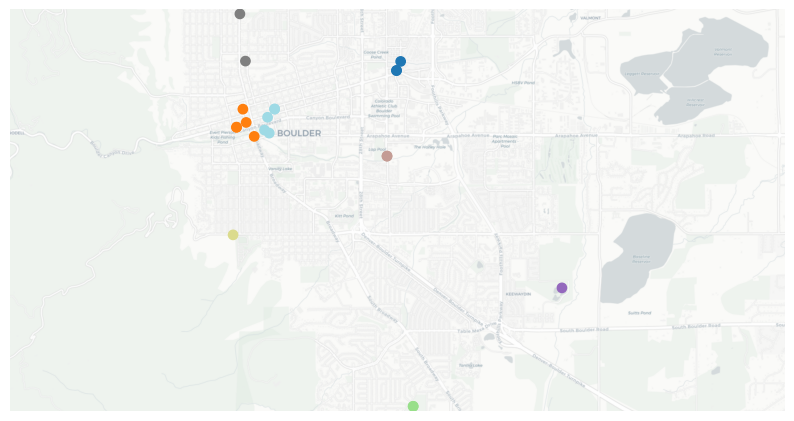

In [ ]:
tmp = df_evcs_meta_available_evse.to_crs(3857).copy()

mbb = tmp.total_bounds
max_width = max(mbb[2]-mbb[0], mbb[3]-mbb[1])
remainder_width, remainder_height = abs(max_width - (mbb[2] - mbb[0])), abs(max_width - (mbb[3] - mbb[1]))


fig, ax = plt.subplots(1,1, figsize=(10, 10/1.618))

if DATA_NAME == 'dundee':
    remainder_width += 1_000
    tmp.plot(ax=ax, column='cluster_id', cmap='tab10', markersize=45)
    ax.set_xlim(mbb[0]-remainder_width/2, mbb[2]+remainder_width/2)
    ax.set_ylim(mbb[1]-1_000, mbb[3]+1_000)

elif DATA_NAME == 'porto':
    tmp.plot(ax=ax, column='cluster_id', cmap='tab20', markersize=45)
    ax.set_xlim(mbb[0]-100-remainder_width/2, mbb[2]+100+remainder_width/2)
    ax.set_ylim(mbb[1]-100-remainder_height/2, mbb[3]+100+remainder_height/2)

elif DATA_NAME == 'boulder':
    remainder_width += 8_000
    tmp.plot(ax=ax, column='cluster_id', cmap='tab20', markersize=45)
    ax.set_xlim(mbb[0]-100-remainder_width/2, mbb[2]+100+remainder_width/2)
    ax.set_ylim(mbb[1]-100-remainder_height/2, mbb[3]+100+remainder_height/2)

elif DATA_NAME == 'paloalto':
    remainder_width += 5_000
    tmp.plot(ax=ax, column='cluster_id', cmap='tab20', markersize=45)
    ax.set_xlim(mbb[0]-100-remainder_width/2, mbb[2]+100+remainder_width/2)
    ax.set_ylim(mbb[1]-remainder_height/2, mbb[3]+remainder_height/2)

ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron, attribution='')

plt.grid(False)
plt.axis(False)
plt.savefig(f'{DATA_NAME}_snapshot_v4.jpeg', dpi=300, bbox_inches='tight')

In [ ]:
df_evse_demand_v3_clusters = df_evse_demand_v3.join(
    df_evcs_meta_available_evse.cluster_id.rename_axis(['oid'])
)

# Save Results

In [15]:
cluster_dataset_dir = os.path.join(
    DATA_PATH, 'pkl', 
    f"{DATA_NAME}_data.demand_{SR_FREQ}_{MIN_POINTS}_points",
)

os.makedirs(
    cluster_dataset_dir, 
    exist_ok=True
)

In [16]:
df_evse_demand_v3_clusters.groupby('cluster_id').apply(
    lambda l: l.to_pickle(
        os.path.join(
            cluster_dataset_dir,
            f"{DATA_NAME}_data.demand_{SR_FREQ}_{MIN_POINTS}_points.enriched.cluster_{l.name}.v4.pickle"
        )
    )
)

/var/folders/p6/kw8t6dgj12v1289kljz8mz4w0000gn/T/ipykernel_94020/267207750.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_evse_demand_v3_clusters.groupby('cluster_id').apply(


""
